In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('../data/Data_for_UCI_named.csv')

In [3]:
df.head(10)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,0.005954,unstable
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,0.016634,unstable
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,-0.038677,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,0.012383,unstable


**Предварительная обработка: удаляем 'stabf', так как это категориальная копия целевой 'stab'**

In [4]:
df = df.drop(columns=['stabf'])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
dtypes: float64(13)
memory usage: 1015.8 KB


In [6]:
df.duplicated().sum()

np.int64(0)

**Все данные заполнены и имеют корректный формат, дубликаты отсутствуют**

<Axes: >

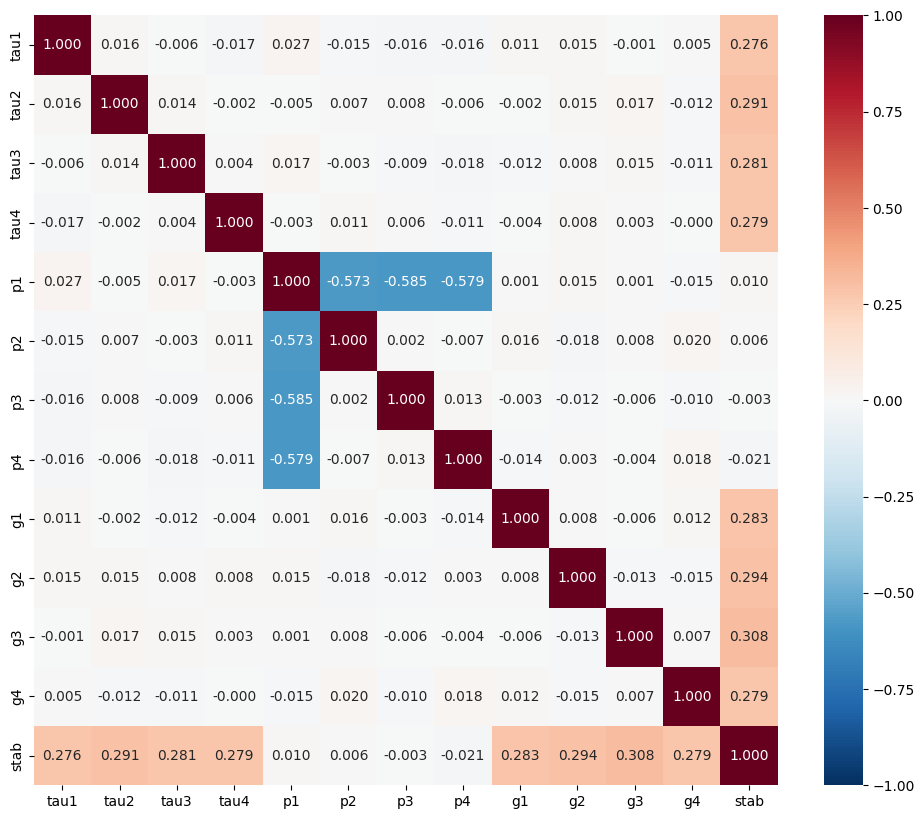

In [7]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.3f', vmin=-1, vmax=1)

- Наибольшая корреляция с переменной 'p1' наблюдается у признаков 'p2', 'p3', 'p4' (коэффициенты ~0.57).
- Присутствует небольшая корреляция с целевой переменной 'stab' у признаков tau1 - tau4 и g1 - g4 (коэффициенты ~0.3).
- Между признаками 'stab' и p корреляция практически отсутствует.


In [8]:
features = df.drop(columns=['stab'])
vif_data = pd.DataFrame()
vif_data["feature"] = features.columns
vif_data["VIF"] = [variance_inflation_factor(features.values, i) for i in range(len(features.columns))]
vif_data

c:\Users\Slava\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,tau1,4.411883
1,tau2,4.373177
2,tau3,4.387577
3,tau4,4.342155
4,p1,inf
5,p2,inf
6,p3,inf
7,p4,inf
8,g1,4.358228
9,g2,4.395410


**Показатели VIF ненормально высоки для признаков p1 - p4**

In [9]:
X = features
y = df['stab']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5)
}

In [10]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    
    results.append({
        "Model": name,
        "Train R2": round(r2_score(y_train, train_pred), 4),
        "Test R2": round(r2_score(y_test, test_pred), 4),
        "Train MSE": round(mean_squared_error(y_train, train_pred), 6),
        "Test MSE": round(mean_squared_error(y_test, test_pred), 6),
        "Train RMSE": round(root_mean_squared_error(y_train, train_pred), 6),
        "Test RMSE": round(root_mean_squared_error(y_test, test_pred), 6),
        "Train MAE": round(mean_absolute_error(y_train, train_pred), 6),
        "Test MAE": round(mean_absolute_error(y_test, test_pred), 6),
        "Train MAPE": round(mean_absolute_percentage_error(y_train, train_pred), 6),
        "Test MAPE": round(mean_absolute_percentage_error(y_test, test_pred), 6),
    })

results_df = pd.DataFrame(results)
results_df.head(3)


,Model,Train R2,Test R2,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train MAPE,Test MAPE
0,Ridge,0.6474,0.6445,0.000481,0.000482,0.021933,0.021960,0.017394,0.017569,2.989070,5.178637
1,Lasso,0.6413,0.6386,0.000489,0.000490,0.022121,0.022140,0.017700,0.017861,2.864545,7.097173
2,ElasticNet,0.6456,0.6433,0.000483,0.000484,0.021989,0.021996,0.017508,0.017665,2.924105,5.981485


**Вывод**

В ходе работы была решена задача регрессии для прогнозирования стабильности энергосетей. Сравнительный анализ моделей Ridge, Lasso и ElasticNet показал следующие результаты:

- Наилучшую точность продемонстрировала Ridge-регрессия с коэффициентом детерминации и минимальными значениями ошибок (RMSE).
- Разница между метриками на обучающей и тестовой выборках минимальна, что подтверждает отсутствие переобучения и эффективность выбранных методов регуляризации.
- Средняя процентная ошибка (MAPE) на тестовых данных составила около 5.2-7.1%, что является хорошим показателем для данной задачи.

Итог: Все модели показали стабильный результат, однако для практического использования рекомендуется Ridge, так как она обеспечила наименьшую погрешность прогноза.
